In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [3]:
data_ace_24 = pd.read_csv("../data/Ace_погружение_24часа.csv", sep=';', decimal=',', parse_dates=['datetime'], index_col='datetime')
data_discover_24 = pd.read_csv("../data/Discover_погружение_24часа.csv", sep=';', decimal=',', parse_dates=['datetime'], index_col='datetime')

In [4]:
def adapt_discover_to_ace(ace_df, disc_df, future_lags, n_comp, split_date="2021-01-01"):
    """
    Перебор компонент для модели адаптации discover-> ace PLSRegression для подбора наилучшего значения
    """
    ace = ace_df.sort_index()
    disc = disc_df.sort_index()
    split_date = pd.Timestamp(split_date)

    ace_train = ace.loc[:split_date]
    disc_train = disc.loc[:split_date]
    disc_test = disc.loc[split_date:]   # адаптируем только тест discover

    # Пересечение индексов внутри train
    overlap_idx = ace_train.index.intersection(disc_train.index)

    ace_overlap = ace_train.loc[overlap_idx]
    disc_overlap = disc_train.loc[overlap_idx]

    feature_cols = [c for c in ace.columns if c not in future_lags]
    
    # Масштабирование
    sc_ace = StandardScaler().fit(ace_overlap[feature_cols])
    sc_disc = StandardScaler().fit(disc_overlap[feature_cols])

    X_ace = sc_ace.transform(ace_overlap[feature_cols])
    X_disc = sc_disc.transform(disc_overlap[feature_cols])

   # Модель адаптации pls с перебором числа компонент
    L = PLSRegression(n_components=n_comp, scale=True, max_iter=2000)

    L.fit(X_disc, X_ace)

    X_disc_test = sc_disc.transform(disc_test[feature_cols])            # Нормировка тестового набора данных discover
    X_disc_test_adapted = L.predict(X_disc_test)                        # Применение обученной модели адаптации
    X_disc_test_adapted = sc_ace.inverse_transform(X_disc_test_adapted) # Приводим новые адаптированные данные к ненормированному виду

    disc_test_adapted = pd.DataFrame(X_disc_test_adapted, index=disc_test.index, columns=feature_cols)

    # Целевые переменные возвращаются обратно неизменёнными
    for col in future_lags:
        disc_test_adapted[col] = disc_test[col]

    return disc_test_adapted

In [5]:
def evaluate_M_A(ace_df, disc_test_adapted_df, split_date, target, future_lags, n_comp):
    """
    Для валидации используются только результаты прогноза линейной модели на 1 час
    """
    split_date = pd.Timestamp(split_date)

    ace_train = ace_df.loc[:split_date]

    feature_cols = [c for c in ace_train.columns if c not in future_lags]

    X_train = ace_train[feature_cols].values
    y_train = ace_train[target].values

    X_test = disc_test_adapted_df[feature_cols].values
    y_test = disc_test_adapted_df[target].values

    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
        
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"n={n_comp}: rmse={rmse:.4f}, mae={mae:.4f}, r2={r2:.4f}")

    return r2

In [6]:
ace = data_ace_24.copy()
disc = data_discover_24.copy()

split_date = "2022-01-01"
future_lags = [f'Dst_plus{i}' for i in range(1, 25)]
target = 'Dst_plus1'

max_n = ace.shape[1]
max_n

224

In [8]:
ns = []
r2s = []

for n_components in range(1, 182, 20):
    disc_test_adapted = adapt_discover_to_ace(
        ace,
        disc,
        future_lags,
        n_components,
        split_date)
    
    res = evaluate_M_A(
        ace,
        disc_test_adapted,
        split_date,
        target,
        future_lags,
        n_components)

    ns.append(n_components)
    r2s.append(res)

n=1: rmse=15.3507, mae=10.3955, r2=0.3217
n=21: rmse=7.3037, mae=5.1305, r2=0.8465
n=41: rmse=6.1816, mae=4.3982, r2=0.8900
n=61: rmse=5.5419, mae=4.0038, r2=0.9116
n=81: rmse=4.8546, mae=3.5213, r2=0.9322
n=101: rmse=4.4865, mae=3.2544, r2=0.9421
n=121: rmse=4.1410, mae=2.9637, r2=0.9506
n=141: rmse=3.8026, mae=2.7040, r2=0.9584
n=161: rmse=3.5202, mae=2.4838, r2=0.9643
n=181: rmse=3.4219, mae=2.4081, r2=0.9663


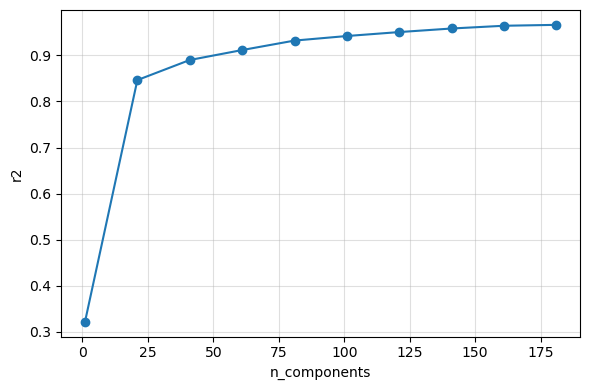

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(ns, r2s, marker='o')
plt.xlabel("n_components")
plt.ylabel("r2")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()